# Homework08

Exercises to practice unsupervised learning with clustering

## Goals

- Get more practice with the ML flow: encode -> normalize -> train -> evaluate
- Understand the tradeoffs of modeling parameters
- Develop intuition for different clustering models and when to use them

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [2]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py

In [3]:
import json
import matplotlib.pyplot as plt
import pandas as pd

from os import listdir
from PIL import Image as PImage

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

from data_utils import balance_score, distance_score, silhouette_score, display_silhouette_plots
from data_utils import object_from_json_url

from image_utils import get_pixels, make_image

## Helmet Sizing

### Load Dataset

Let's load up the full [ANSUR](https://www.openlab.psu.edu/ansur2/) dataset that we looked at briefly in [Week 02](https://github.com/PSAM-5020-2026S-A/WK02) and then again in [Homework06](https://github.com/PSAM-5020-2026S-A/Homework06).

This is the dataset that has anthropometric information about U.S. Army personnel.

#### WARNING

Like we mentioned in class, this dataset is being used for these exercises due to the level of detail in the dataset and the rigorous process that was used in collecting the data.

This is a very specific dataset and should not be used to draw general conclusions about people, bodies, or anything else that is not related to the distribution of physical features of U.S. Army personnel.

In [4]:
# Load Dataset
ANSUR_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur.json"
ansur_data = object_from_json_url(ANSUR_FILE)

# Look at first 2 records
ansur_data[:2]

[{'age': 18,
  'gender': 'F',
  'height': 66,
  'weight': 135,
  'span': 1699,
  'stature': 1645,
  'ear': {'breadth': 30, 'length': 61, 'protrusion': 20},
  'foot': {'breadth': 97, 'length': 243},
  'hand': {'breadth': 78, 'length': 182, 'palm': 108},
  'head': {'height': 243, 'circumference': 557}},
 {'age': 30,
  'gender': 'M',
  'height': 68,
  'weight': 207,
  'span': 1749,
  'stature': 1715,
  'ear': {'breadth': 35, 'length': 63, 'protrusion': 17},
  'foot': {'breadth': 100, 'length': 252},
  'hand': {'breadth': 87, 'length': 184, 'palm': 114},
  'head': {'height': 238, 'circumference': 560}}]

Let's load it into a `DataFrame`, like last week.

In [5]:
# Read into DataFrame
ansur_df = pd.json_normalize(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear.breadth,ear.length,ear.protrusion,foot.breadth,foot.length,hand.breadth,hand.length,hand.palm,head.height,head.circumference
0,18,F,66,135,1699,1645,30,61,20,97,243,78,182,108,243,557
1,30,M,68,207,1749,1715,35,63,17,100,252,87,184,114,238,560
2,27,M,67,121,1684,1657,36,59,24,92,251,84,180,103,239,516
3,20,M,73,185,1878,1828,36,60,21,104,280,95,201,124,270,582
4,33,M,76,150,1977,1883,39,65,27,101,271,90,194,113,254,559


### Unsupervised Learning

Let's pretend we are designing next-generation helmets with embedded over-the-ear headphones and we want to have a few options for sizes.

We could use clustering to see if there is a number of clusters that we can divide our population into, so each size covers a similar portion of the population.

We can follow similar steps to regression to create a clustering model that uses features about head and ear sizes:

1. Load dataset (done! 🎉)
2. Encode label features as numbers
3. Normalize the data
4. Separate the feature variables we want to consider (done below)
5. Pick a clustering algorithm
6. Determine number of clusters
7. Cluster data
8. Interpret results

For step $5$, it's fine to just pick an algorithm ahead of time to see what happens, but feel free to experiment and plot results for multiple clustering methods.

In [6]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

## Encode non-numerical features
encoder = OrdinalEncoder()
ansur_df[['gender']] = encoder.fit_transform(ansur_df[['gender']])

## Normalize the data
scaler = StandardScaler()
ansur_scaled_df = pd.DataFrame(
    scaler.fit_transform(ansur_df),
    columns=ansur_df.columns
)

print(ansur_scaled_df.shape)
ansur_scaled_df.head()

(5600, 16)


,age,gender,height,weight,span,stature,ear.breadth,ear.length,ear.protrusion,foot.breadth,foot.length,hand.breadth,hand.length,hand.palm,head.height,head.circumference
0,-1.356245,-1.433562,-0.580787,-1.172301,-0.583101,-0.768824,-1.595311,-0.339199,-0.716543,-0.278534,-1.148478,-1.091728,-0.631450,-0.829835,-0.520526,-0.712215
1,0.029404,0.697563,-0.063917,0.961397,-0.132506,0.008154,-0.040102,0.075180,-1.664859,0.172925,-0.631455,0.324677,-0.457501,0.011265,-0.942284,-0.548648
2,-0.317008,0.697563,-0.322352,-1.587187,-0.718280,-0.635628,0.270940,-0.753577,0.547878,-1.030966,-0.688902,-0.147458,-0.805398,-1.530751,-0.857933,-2.947621
3,-1.125304,0.697563,1.228259,0.309434,1.030031,1.262420,0.270940,-0.546388,-0.400438,0.774871,0.977061,1.583704,1.021064,1.413097,1.756972,0.650838
4,0.375816,0.697563,2.003565,-0.727781,1.922210,1.872903,1.204065,0.489559,1.496194,0.323411,0.460038,0.796812,0.412243,-0.128919,0.407344,-0.603170


In [7]:
## Separate the features we want to consider
ansur_features = ansur_scaled_df[["head.height", "head.circumference", "ear.length", "ear.breadth", "ear.protrusion"]]

(5600, 4)
Inertia (lower is better): 12465.1283


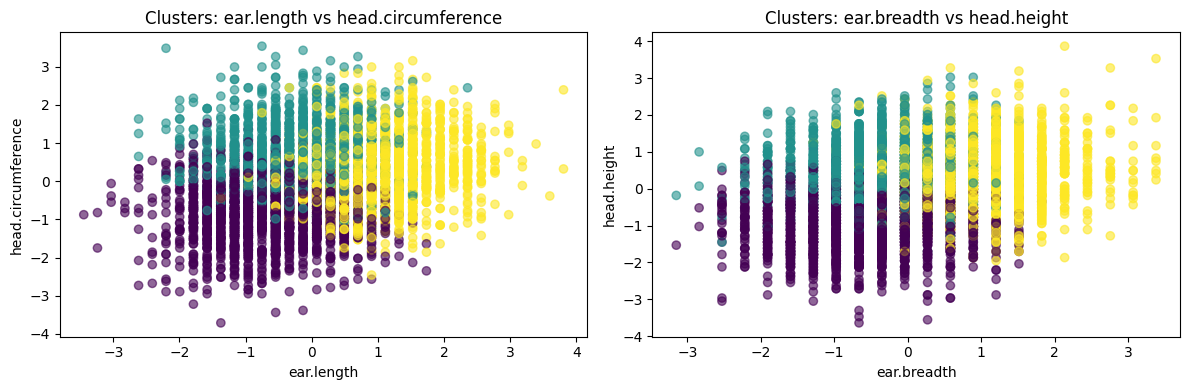

In [8]:
## Separate relevant features
cluster_features = ansur_scaled_df[['ear.length', 'ear.breadth', 'head.circumference', 'head.height']]
print(cluster_features.shape)

## Run the model on the data
N_CLUSTERS = 3  # adjust based on silhouette plot results
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)
cluster_labels = kmeans.fit_predict(cluster_features)

## Check errors
inertia = kmeans.inertia_
print(f"Inertia (lower is better): {inertia:.4f}")

## Plot clusters as function of 2 variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ear.length vs head.circumference
axes[0].scatter(cluster_features['ear.length'],
                cluster_features['head.circumference'],
                c=cluster_labels, cmap='viridis', alpha=0.6)
axes[0].set_xlabel('ear.length')
axes[0].set_ylabel('head.circumference')
axes[0].set_title('Clusters: ear.length vs head.circumference')

# ear.breadth vs head.height
axes[1].scatter(cluster_features['ear.breadth'],
                cluster_features['head.height'],
                c=cluster_labels, cmap='viridis', alpha=0.6)
axes[1].set_xlabel('ear.breadth')
axes[1].set_ylabel('head.height')
axes[1].set_title('Clusters: ear.breadth vs head.height')

plt.tight_layout()
plt.show()

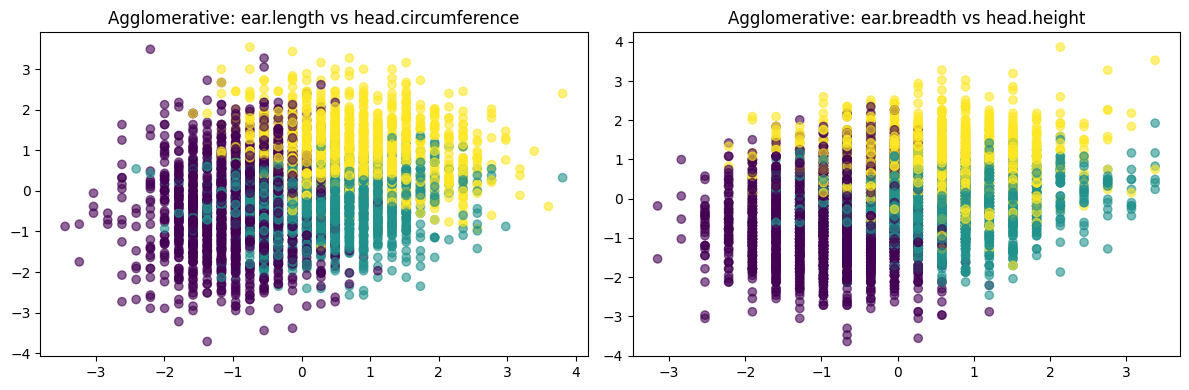

In [9]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(cluster_features)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(cluster_features['ear.length'],
                cluster_features['head.circumference'],
                c=agglo_labels, cmap='viridis', alpha=0.6)
axes[0].set_title('Agglomerative: ear.length vs head.circumference')

axes[1].scatter(cluster_features['ear.breadth'],
                cluster_features['head.height'],
                c=agglo_labels, cmap='viridis', alpha=0.6)
axes[1].set_title('Agglomerative: ear.breadth vs head.height')
plt.tight_layout()
plt.show()

### Interpretation

<span style="color:hotpink;">
Which clustering algorithm did you choose?<br>
Did you try a different one?<br>
Do the clusters make sense ? Do they look balanced ?
</span>

<span style="color:hotpink;"> I used kmeans with 3 clusters. I used kmeans because I was looking for distinct size groupings. Then I tried agglomorative clustering. I think the kmeans works better because it seems more balanced and the groupings have fewer outliers. The kmeans clusters do look balanced. </span>

## Figure out how many cluster

Experiment with the number of clusters to see if the initial choice makes sense.

The [WK08](https://github.com/PSAM-5020-2026S-A/WK08) notebook had a for loop that can be used to plot errors versus number of clusters.

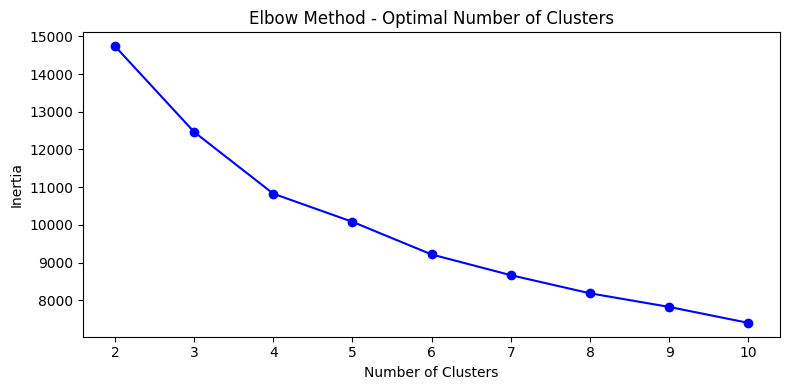

In [10]:
## Plot errors and pick how many cluster
from sklearn.cluster import KMeans

## Plot errors and pick how many clusters
inertias = []
n_clusters_range = range(2, 11)

for n in n_clusters_range:
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(cluster_features)
    inertias.append(kmeans.inertia_)

## Plot elbow curve
plt.figure(figsize=(8, 4))
plt.plot(n_clusters_range, inertias, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xticks(n_clusters_range)
plt.tight_layout()
plt.show()

### Interpretation

<span style="color:hotpink;">
Based on the graphs of errors versus number of clusters, does it look like we should change the initial number of clusters ?<br>
How many clusters should we use ? Why ?
</span>

<span style="color:hotpink;">I think we might want to use 3-5 clusters. Because they are helmets I think 3 clusters makes sense due to s/m/l unless we want to do xs/xl. The curve gets flatter around 4 or 5. </span>

### Revise Number of Clusters.

Re-run with the new number of clusters and plot the data in $2D$ or $3D$.

This can be the same graph as above.

Inertia: 10827.9680
Cluster 0: 1515 people (27.1%)
Cluster 1: 1429 people (25.5%)
Cluster 2: 1299 people (23.2%)
Cluster 3: 1357 people (24.2%)


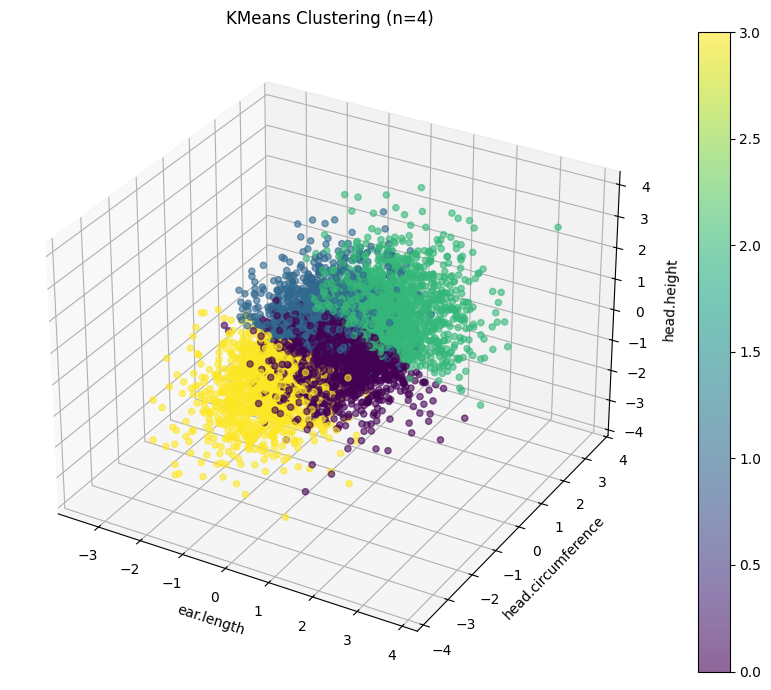

In [11]:
from mpl_toolkits.mplot3d import Axes3D

## Re-run clustering with final number of clusters
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)

## Run the model on the training data
cluster_labels = kmeans.fit_predict(cluster_features)

## Check errors
print(f"Inertia: {kmeans.inertia_:.4f}")

# print cluster sizes to check balance
import numpy as np
unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} people ({count/len(cluster_labels)*100:.1f}%)")

## Plot in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    cluster_features['ear.length'],
    cluster_features['head.circumference'],
    cluster_features['head.height'],
    c=cluster_labels,
    cmap='viridis',
    alpha=0.6
)

ax.set_xlabel('ear.length')
ax.set_ylabel('head.circumference')
ax.set_zlabel('head.height')
ax.set_title(f'KMeans Clustering (n={N_CLUSTERS})')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()

### Interpretation

<span style="color:hotpink;">
Do these look better than the original number of clusters?
</span>

<span style="color:hotpink;">Yes, this definitely looks better and the groupings seem even more balanced.</span>

## Image Organization

We have a dataset of about $600$ flower images that we might want to classify by species... eventually.

What we want to do first is take a look at all of the images and see what kind of images we have, what kind of colors our flowers have and see if there's any other visual information that could help us classify these images later.

We'll see how to use clustering and distances to organize our images by color to create a visualization that we cna use to get to know our dataset.

### Load Dataset

The following cell downloads the dataset:

In [12]:
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/flowers.tar.gz | tar xz

Then, we can take a look at a few of the images:

In [13]:
IMG_DIR = "./data/image/flowers"

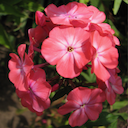

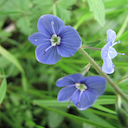

In [14]:
display(PImage.open(f"{IMG_DIR}/00_001.png"))
display(PImage.open(f"{IMG_DIR}/15_001.png"))

### Find Representative Colors

The overall process for organizing our images by color will be something like this:

1. Iterate over all files in the `data/image/flowers` directory, open each image file and treat it as a dataset
   1. Load image into a `DataFrame` where each pixel is a row and R,G,B values are columns/features
   2. Cluster into $2$ - $16$ colors
   3. Pick $3$ or $4$ representative colors
   4. Store image filenames and their representative colors in a Python object
2. Once all images have been processed we can order our dataset by different color characteristics: white to black, red to blue, hue value, brightness

### One Image

Let's step through the process of getting representative colors for one image, and then we can repeat this in a loop to process all of the flower images.

#### Open Image

The `PIL` library does all the work here:

In [15]:
# Open image
fname = "00_001.png"
pimg = PImage.open(f"{IMG_DIR}/{fname}").convert("RGB")

#### Put into `DataFrame`

We get the pixels and make a dataset/`DataFrame` out of them:

In [16]:
# Load into DataFrame
pxs = get_pixels(pimg)
pxs_df = pd.DataFrame(pxs, columns=["R", "G", "B"])

#### Cluster colors

Create a clustering object, cluster colors into $8$ clusters with `fit_predict()` and take a look at our color palette (`cluster_centers_`):

Representative colors (R, G, B):
  Color 0: R=12, G=14, B=10
  Color 1: R=184, G=86, B=114
  Color 2: R=245, G=134, B=159
  Color 3: R=139, G=37, B=52
  Color 4: R=67, G=84, B=32
  Color 5: R=242, G=108, B=128
  Color 6: R=246, G=177, B=203
  Color 7: R=108, G=25, B=32
  Color 8: R=140, G=154, B=79
  Color 9: R=56, G=49, B=29
  Color 10: R=192, G=47, B=65
  Color 11: R=94, G=71, B=48
  Color 12: R=223, G=77, B=95
  Color 13: R=31, G=32, B=18
  Color 14: R=98, G=111, B=48
  Color 15: R=153, G=58, B=79


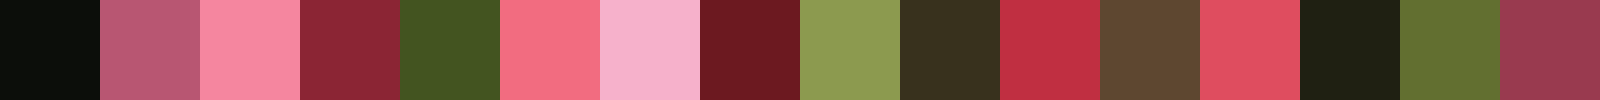

In [17]:
from sklearn.cluster import KMeans

# Open image
fname = "00_001.png"
pimg = PImage.open(f"{IMG_DIR}/{fname}").convert("RGB")

# Load into DataFrame
pxs = get_pixels(pimg)
pxs_df = pd.DataFrame(pxs, columns=["R", "G", "B"])

# TODO: Create Clustering object
N_COLORS = 16
kmeans = KMeans(n_clusters=N_COLORS, random_state=42)

# TODO: Cluster by color
kmeans.fit(pxs_df)

# TODO: Take a look at the color palette (cluster_centers_)
palette = kmeans.cluster_centers_.astype(int)
print("Representative colors (R, G, B):")
for i, color in enumerate(palette):
    print(f"  Color {i}: R={color[0]}, G={color[1]}, B={color[2]}")

# Visualize the palette
palette_img = PImage.new("RGB", (100 * N_COLORS, 100))
for i, color in enumerate(palette):
    for x in range(100 * i, 100 * (i + 1)):
        for y in range(100):
            palette_img.putpixel((x, y), tuple(color))

display(palette_img)

#### Checkpoint

<span style="color:hotpink;">
Does anything stand out about the colors?
</span>

<span style="color:hotpink;">Maybe that they are mostly all shades of red, so we are likely losing some of the more intricate color details. </span>

#### Reconstruct Image

Since we're only doing one image for now, let's take a look at the clustering result.

This is like in the lecture notebook. We'll start with an empty pixel array and as we iterate through the `DataFrame` of cluster ids we append the corresponding colors to it.

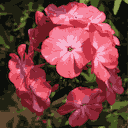

In [18]:
# TODO: create empty pixel array
pxs_post = []

# TODO: iterate through resulting list of cluster ids
for cluster_id in kmeans.labels_:
    # TODO: append corresponding color value to pixel array
    pxs_post.append(tuple(palette[cluster_id]))

# Reconstruct and display the recolored image
width, height = pimg.size
recolored_img = PImage.new("RGB", (width, height))
recolored_img.putdata(pxs_post)
display(recolored_img)

Now we can look at the image. If this next cell gives errors about using `float` values in images, just make sure the pixel values that are being appended above are all whole number `int` values.

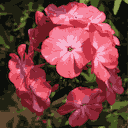

In [19]:
display(make_image(pxs_post, width=pimg.size[0]))

#### Checkpoint

<span style="color:hotpink;">
How does changing the number of clusters affect the resulting image?<br>Try some lower values like <code>2</code> and <code>4</code>, and also some higher ones like <code>12</code> and <code>16</code>. Take a look at a different image.
</span>

<span style="color:hotpink;">When we use more clusters, we see more detail in the image. The fewer clusters we use the less detailed the image is. Using only 2 clusters loses lots of the details that the image had. </span>

#### Pick Colors

Ok, we have some representative colors for our images. We should keep more than one color, but maybe we don't have to keep $12$.

If we put our predictions in a `DataFrame` we can use the `value_counts()` function of our `DataFrame` to see how many pixels are represented by each of our cluster colors, and get the result ordered by most frequent to less frequent cluster id:

In [20]:
# cluster ids and pixel counts, ordered by descending counts
# define px_clusters from kmeans labels
px_clusters = kmeans.labels_
px_clusters_df = pd.DataFrame(px_clusters, columns=["clusters"])
ccounts = px_clusters_df["clusters"].value_counts()
display(ccounts)

clusters
13    2337
0     2083
3     1433
5     1386
9     1284
2     1183
7     1172
12     980
10     954
11     737
15     673
4      644
6      636
1      424
14     359
8       99
Name: count, dtype: int64

Since what we are really trying to do here is get some information about the colors of the flowers present in our images, and given the type of images we have, we can start by assuming that the flower colors will be in the top-$4$ clusters returned by `value_counts()`.

We can revisit this assumption later. We might also want to add some filters here to ignore sky and vegetation colors (blues and greens) and only keep flower colors.

For now, let's just grab the top $4$ colors from `value_counts()`, remembering we want to keep their rounded `int` values and not the default `float` values in `cluster_centers_`.

In [21]:
# Object to keep colors for each file
file_info = {
    "filename": fname,
    "colors": []
}

# TODO: go through ccounts.index and get corresponding colors for each clusters
for cluster_id in ccounts.index[:4]:  # top 4 most common clusters
    color = tuple(palette[cluster_id])
    # TODO: add top-4 colors to the "colors" key of the file_color_info object
    file_info["colors"].append(color)

print(file_info)

{'filename': '00_001.png', 'colors': [(np.int64(31), np.int64(32), np.int64(18)), (np.int64(12), np.int64(14), np.int64(10)), (np.int64(139), np.int64(37), np.int64(52)), (np.int64(242), np.int64(108), np.int64(128))]}


In [22]:
display(file_info)

{'filename': '00_001.png',
 'colors': [(np.int64(31), np.int64(32), np.int64(18)),
  (np.int64(12), np.int64(14), np.int64(10)),
  (np.int64(139), np.int64(37), np.int64(52)),
  (np.int64(242), np.int64(108), np.int64(128))]}

#### Checkpoint

<span style="color:hotpink;">
Why might we want to cluster into <code>8</code> or even <code>12</code> colors when in the end we're only keeping <code>4</code>?
</span>

<span style="color:hotpink;">I think that this is because when you cluster into 8 or 12 groups first before splitting into 4 then the groups are more refined and accurate, whereas if you just separate into 4 from the beginning the groups might make less sense in the long term and you might lose more detail by accident. </span>

### Iterate and Cluster

We've processed one image, now let's process $600$... for-loops FTW!

We'll need to loop through all of the images in our directory and repeat the process above for each one of them.

We can create a function that takes a filename as input and returns the top-$4$ colors for that image, or... we can just put all of the clustering logic in the body of a for loop. Whichever is easiest.

Let's get started.

In [23]:
# list of all files in the flowers directory
flower_files = sorted([f for f in listdir(IMG_DIR) if f.endswith(".png")])

Here's the loop. In the end we want our `file_colors` list to have objects that have a filename and $4$ colors associated with each filename. Something like:

```py
[
  {
    "filename": "00_001.png",
    "colors": [[12,44,12], [112,144,62],  [12,84,112], [212,144,102]]
  },
  {
    "filename": "00_002.png",
    "colors": [[22,24,28], [112,114,122], [128,200,2], [250,240,230]]
  },
  ...
]
```

This can take a while to run (up to a minute for $600$ images). We can use slicing to test our logic on a subset of `flower_files` before processing all $600$ images.

In [24]:
# List to keep colors for each file
file_colors = []

# TODO: get colors for each image
for fname in flower_files[:10]:  # test on 10 first, then change to flower_files
    # open and convert image
    pimg = PImage.open(f"{IMG_DIR}/{fname}").convert("RGB")
    
    # load into DataFrame
    pxs = get_pixels(pimg)
    pxs_df = pd.DataFrame(pxs, columns=["R", "G", "B"])
    
    # cluster into 8 colors for better separation
    kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
    kmeans.fit(pxs_df)
    
    # get palette and pixel counts
    palette = kmeans.cluster_centers_.astype(int)
    px_clusters = kmeans.labels_
    px_clusters_df = pd.DataFrame(px_clusters, columns=["clusters"])
    ccounts = px_clusters_df["clusters"].value_counts()
    
    # get top 4 colors by pixel count
    top_colors = []
    for cluster_id in ccounts.index[:4]:
        color = tuple(palette[cluster_id])
        top_colors.append(color)
    
    # TODO: add filename+colors object to list of objects
    file_colors.append({
        "filename": fname,
        "colors": top_colors
    })

print(f"Processed {len(file_colors)} images")
print(file_colors[0])

Processed 10 images
{'filename': '00_001.png', 'colors': [(np.int64(20), np.int64(22), np.int64(14)), (np.int64(56), np.int64(50), np.int64(28)), (np.int64(122), np.int64(31), np.int64(42)), (np.int64(243), np.int64(119), np.int64(141))]}


#### Order Images (almost)

We have a list with objects that keep track of filenames and representative colors. We could create a `DataFrame` or csv dataset with these, but let's go ahead and just use this directly in this format.

What we want to do is re-order our list of objects, but using a `key` function that takes each object's colors into consideration.

We'll look into how to do this dynamically later, but for now let's order our images by something like _brightness_. It's _like_ brightness because what we'll do is measure how close each image is to the white color `(255,255,255)`.

We'll need some helper functions first:

- `color_distance()`: takes $2$ colors and returns the distance between them
- `min_color_distance()`: given a reference color and a list of colors, returns the distance between the reference color and the closest color in the list

In [25]:
import numpy as np

# TODO: implement function that returns distance between two colors
def color_distance(c0, c1):
    # calculate Euclidean distance between two RGB colors
    c0_np = np.array(c0)
    c1_np = np.array(c1)
    return np.sqrt(np.sum((c0_np - c1_np) ** 2))

# test it
print(color_distance((255, 0, 0), (0, 0, 255)))  # red vs blue - should be large
print(color_distance((255, 0, 0), (254, 0, 0)))  # almost same red - should be small
print(color_distance((0, 0, 0), (255, 255, 255))) # black vs white - should be largest

360.62445840513925
1.0
441.6729559300637


Some tests for the `color_distance()` function:

In [26]:
# Some tests for the color_distance() function
print(color_distance([0,0,0], [255,255,255]), "should be", 255*3**.5)
print(color_distance([0,100,0], [100,100,0]), "should be", 100)
print(color_distance([55,222,120], [91,51,192]), "should be", 189)
print(color_distance([147,207,246], [87,57,50]), "should be", 254)
print(color_distance([12,250,126], [112,10,195]), "should be", 269)
print(color_distance([106,71,61], [105,136,100]), "should be", 75.81)

441.6729559300637 should be 441.67295593006367
100.0 should be 100
189.0 should be 189
254.0 should be 254
269.0 should be 269
75.80897044545586 should be 75.81


In [27]:
# TODO: implement function that returns minimum distance between a reference color and colors from a list
def min_color_distance(ref_color, color_list):
    # calculate distance from ref_color to each color in list
    distances = [color_distance(ref_color, c) for c in color_list]
    return min(distances)

# test it
ref = (255, 0, 0)  # red
colors = [(0, 0, 255), (200, 0, 0), (0, 255, 0)]  # blue, dark red, green
print(min_color_distance(ref, colors))  # should return small value for dark red

55.0


Three tests for the `min_color_distance()` function:

In [28]:
# Some tests for the color_distance() function
print(min_color_distance([0,0,0], [[255,255,255],[0,100,0],[100,100,0],[58,58,58]]), "should be", 100)
print(min_color_distance([0,0,0], [[255,255,255],[0,100,0],[100,100,0],[58,57,58]]), "should be", 99.88)
print(min_color_distance([91,51,192], [[147,207,246],[87,57,50],[12,250,126],[112,10,195]]), "should be", 46.16)

100.0 should be 100
99.88493379884676 should be 99.88
46.16275555033516 should be 46.16


#### Order Images (for real now)

Alright. We have a function that can be used to order our images by their distance to a given color.

Let's order our images by how close they are to the brightest color `(255,255,255)`. We'll define a `key` function that, given an object from our `file_colors` list, returns how close that image is to the color `(255,255,255)`.

In [29]:
# TODO: implement function that returns how close our image is to the color white
def by_bright_dist(A):
  # TODO: add logic here
  return 0 # TODO: Change this

Order the list and write out a `JSON` file with the image order.

In [30]:
file_colors_sorted = sorted(file_colors, key=by_bright_dist)

In [31]:
files_sorted = [A["filename"] for A in file_colors_sorted]

with open("./data/flower_order.json", "w") as ofp:
  json.dump(files_sorted, ofp)

### Viewing Results

We can check the results by running a webserver and looking at a simple web page that orders the images according to the resulting `JSON` file from above.

We'll make use of the [`Live Server`](https://marketplace.visualstudio.com/items?itemName=ritwickdey.LiveServer) VSCode extension.

We can start the server by clicking on the "_Go Live_" button towards the right hand side of the bar at the very bottom of our text editor:

<img src="./imgs/go_live.jpg" width="600px">

Clicking the "_Go Live_" button in Codespace should open up a new tab with a plain html navigation view of our repository. Clicking on the `html/` directory should open up a web page with all of the flower images. If not, you can use your Codespace url to try to find the web server address.

If your Codespace url is something like:<br>`https://mango-special-giggle-v6v7asd322f7p6.github.dev/`

Then, the webserver should be running at:<br>`https://mango-special-giggle-v6v7asd322f7p6-5500.app.github.dev/`

### Review, Contemplate, Experiment

Yes, images with white parts are towards the beginning, but the images towards the end aren't necessarily the ones with dark flowers, but are the ones that have all of their representative colors farthest away from white `(255,255,255)`, which includes very saturated colors/images.

A couple of interesting experiments here could be:
- Decrease the number of clusters or the number of colors kept after clustering.
- Use different colors as the reference for the distance functions. For example, create `by_gold_dist()` or `by_purple_dist()` functions to use as the `key` for sorting.
- Order the list of cluster colors by [hue](https://stackoverflow.com/questions/23090019/fastest-formula-to-get-hue-from-rgb). This can be a bit tricky to get right because some colors, like white, black and gray, don't have a unique value for hue, but depend on other aspects of the color, like saturation and lightness, to be well-defined.

In [32]:
import colorsys

# 1. EXPERIMENT WITH DIFFERENT REFERENCE COLORS
def by_color_dist(A, ref_color):
    return min_color_distance(ref_color, A["colors"])

# sort by different reference colors
red   = (255, 0, 0)
blue  = (0, 0, 255)
green = (0, 255, 0)
black = (0, 0, 0)

sorted_by_red   = sorted(file_colors, key=lambda x: by_color_dist(x, red))
sorted_by_blue  = sorted(file_colors, key=lambda x: by_color_dist(x, blue))
sorted_by_green = sorted(file_colors, key=lambda x: by_color_dist(x, green))
sorted_by_dark  = sorted(file_colors, key=lambda x: by_color_dist(x, black))

print("Closest to red:",   sorted_by_red[:3])
print("Closest to blue:",  sorted_by_blue[:3])
print("Closest to green:", sorted_by_green[:3])
print("Closest to dark:",  sorted_by_dark[:3])

# 2. EXPERIMENT WITH HUE DISTANCE
def get_hue(color):
    r, g, b = [x/255.0 for x in color]
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    return h

def by_hue(A):
    # return average hue of top colors
    hues = [get_hue(c) for c in A["colors"]]
    return sum(hues) / len(hues)

sorted_by_hue = sorted(file_colors, key=by_hue)
print("\nSorted by hue - first 3:", [f["filename"] for f in sorted_by_hue[:3]])
print("Sorted by hue - last 3:",  [f["filename"] for f in sorted_by_hue[-3:]])

# 3. EXPERIMENT WITH NUMBER OF TOP COLORS KEPT
def by_bright_dist_topN(A, n=2):
    white = (255, 255, 255)
    return min_color_distance(white, A["colors"][:n])

sorted_top2 = sorted(file_colors, key=lambda x: by_bright_dist_topN(x, n=2))
sorted_top4 = sorted(file_colors, key=lambda x: by_bright_dist_topN(x, n=4))

print("\nTop 2 colors sorting - first 3:", [f["filename"] for f in sorted_top2[:3]])
print("Top 4 colors sorting - first 3:", [f["filename"] for f in sorted_top4[:3]])

Closest to red: [{'filename': '00_003.png', 'colors': [(np.int64(211), np.int64(47), np.int64(86)), (np.int64(234), np.int64(72), np.int64(111)), (np.int64(185), np.int64(25), np.int64(61)), (np.int64(246), np.int64(100), np.int64(147))]}, {'filename': '00_004.png', 'colors': [(np.int64(53), np.int64(64), np.int64(34)), (np.int64(29), np.int64(36), np.int64(20)), (np.int64(244), np.int64(93), np.int64(137)), (np.int64(233), np.int64(68), np.int64(105))]}, {'filename': '00_001.png', 'colors': [(np.int64(20), np.int64(22), np.int64(14)), (np.int64(56), np.int64(50), np.int64(28)), (np.int64(122), np.int64(31), np.int64(42)), (np.int64(243), np.int64(119), np.int64(141))]}]
Closest to blue: [{'filename': '00_002.png', 'colors': [(np.int64(26), np.int64(30), np.int64(20)), (np.int64(164), np.int64(69), np.int64(157)), (np.int64(186), np.int64(93), np.int64(186)), (np.int64(214), np.int64(124), np.int64(217))]}, {'filename': '00_007.png', 'colors': [(np.int64(204), np.int64(148), np.int64(1

In [34]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_sorted_images(sorted_list, n=20, title="Sorted Images"):
    fig, axes = plt.subplots(1, n, figsize=(40, 4))
    fig.suptitle(title)
    for i, file_info in enumerate(sorted_list[:n]):
        img = mpimg.imread(f"{IMG_DIR}/{file_info['filename']}")
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()



### Interpretation

<span style="color:hotpink;">
What did you try ? What happened ?
</span>

<span style="color:hotpink;"> I tried sorting image colors by distance to different reference colors. I also tried sorting by hue value. I also tried keeping only the top 2 dominant colors vs the top 4 to see how background colors affect sorting. The first method worked well for pulling flowers of a specific color to the top. Hue sorting created a nice gradient of color. I am struggling with going live to see the images though, can we go over this more in class? </span>

### Conclusion

It's challenging to define a set of functions that will perfectly order our flowers by color without first having to define very specific color values for filtering and corner-cases. At a high-level, we can imagine that this is because color is a $3$-dimensional value, and we're using it to organize our images into a single-dimensional order.

The beginning of our ordering is usually pretty good, since there's only one way for a color to be _close_ to our reference color, but the ordering gets less consistent towards the end because there are many different ways for a color to be _far_ from the reference color.

Next week we'll see a very powerful technique that, amongst other things, will help us get around this kind of "_dimensionality mismatch_".